## 1. Import Libraries

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix as cm_func

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Datasets

In [93]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
gender_submission = pd.read_csv("gender_submission.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Data Preprocessing

In [94]:
# 3. Data Preprocessing
# Reload fresh data to avoid issues from multiple runs
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

train_df = train_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')  # Drop irrelevant columns
test_df = test_df.drop(['Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')  # Drop irrelevant columns, keep PassengerId for submission

# Encode categorical variables
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})  # Convert categorical variable to numerical    
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})  # Convert categorical variable to numerical  

# Fill missing values in Embarked - handle mode safely
embarked_mode = train_df['Embarked'].mode()
embarked_fill_value = embarked_mode[0] if len(embarked_mode) > 0 else 'S'
train_df['Embarked'] = train_df['Embarked'].fillna(embarked_fill_value)
test_df['Embarked'] = test_df['Embarked'].fillna(embarked_fill_value)

train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})  # Convert categorical variable to numerical      
test_df['Embarked'] = test_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})  # Convert categorical variable to numerical

# Handle missing values in Age column by filling with the median age
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())

# Handle missing values in Fare column
train_df['Fare'] = train_df['Fare'].fillna(train_df['Fare'].median())
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

# Fill any remaining NaN values with 0
train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

# Feature engineering: Create new features
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1  # +1 to include the passenger themselves
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1  # +1 to include the passenger themselves   

train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)  # 1 if alone, 0 otherwise
test_df['IsAlone'] = (test_df['FamilySize'] == 1).astype(int)  # 1 if alone, 0 otherwise    

print("Data preprocessing completed.")
print("Missing values in train_df:\n", train_df.isnull().sum())
print("Missing values in test_df:\n", test_df.isnull().sum())


Data preprocessing completed.
Missing values in train_df:
 Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
dtype: int64
Missing values in test_df:
 PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
FamilySize     0
IsAlone        0
dtype: int64


## 4. Train/Validation Split

In [95]:

# 4. Split Dataset
X = train_df.drop('Survived', axis=1)  # Features
y = train_df['Survived']  # Target variable
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset split into training and validation sets.")

Dataset split into training and validation sets.


## 5. Logistic Regression

In [96]:
# 5. Model Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Validate Model
y_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)    
cm = cm_func(y_val, y_pred)  # Using aliased function to avoid naming conflicts

print("Validation Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)


Validation Accuracy: 0.7988826815642458
Confusion Matrix:
 [[90 15]
 [21 53]]


In [97]:
# Predict on Test Set
test_predictions = model.predict(test_df.drop('PassengerId', axis=1))  # Drop PassengerId for prediction

# Create submission File
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],  # Use PassengerId from test_df
    'Survived': test_predictions
})

submission.to_csv("submission1.csv", index=False)
print("Submission file created: submission1.csv successfully.")


Submission file created: submission1.csv successfully.


## 6. Decision Tree

In [98]:
# 6. Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_val)
print("Decision Tree Validation Accuracy:", accuracy_score(y_val, y_pred_dt))
print("Decision Tree Confusion Matrix:\n", cm_func(y_val, y_pred_dt))   

Decision Tree Validation Accuracy: 0.7877094972067039
Decision Tree Confusion Matrix:
 [[86 19]
 [19 55]]


## 7. Random Forest

In [99]:
# 7. Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)
print("Random Forest Validation Accuracy:", accuracy_score(y_val, y_pred_rf))   
print("Random Forest Confusion Matrix:\n", cm_func(y_val, y_pred_rf))

Random Forest Validation Accuracy: 0.8212290502793296
Random Forest Confusion Matrix:
 [[90 15]
 [17 57]]


## 8 Pipelines & Scaling

In [100]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Logistic Regression Pipeline with scaling
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),   # scale features
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_lr.fit(X_train, y_train)
y_pred_pipe_lr = pipeline_lr.predict(X_val)

print("Pipeline Logistic Regression Accuracy:", accuracy_score(y_val, y_pred_pipe_lr))
print("Pipeline Logistic Regression Confusion Matrix:\n", cm_func(y_val, y_pred_pipe_lr))

# Random Forest Pipeline (scaling not needed, but included for consistency)
pipeline_rf = Pipeline([
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42))
])

pipeline_rf.fit(X_train, y_train)
y_pred_pipe_rf = pipeline_rf.predict(X_val)

print("Pipeline Random Forest Accuracy:", accuracy_score(y_val, y_pred_pipe_rf))
print("Pipeline Random Forest Confusion Matrix:\n", cm_func(y_val, y_pred_pipe_rf))


Pipeline Logistic Regression Accuracy: 0.7988826815642458
Pipeline Logistic Regression Confusion Matrix:
 [[90 15]
 [21 53]]
Pipeline Random Forest Accuracy: 0.8156424581005587
Pipeline Random Forest Confusion Matrix:
 [[89 16]
 [17 57]]


## 9. Model Comparison

In [101]:
# Compare Models side by side
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_score(y_val, y_pred),
                 accuracy_score(y_val, y_pred_dt),
                 accuracy_score(y_val, y_pred_rf)]
})      

print("\nModel Comparison:\n", results)


Model Comparison:
                  Model  Accuracy
0  Logistic Regression  0.798883
1        Decision Tree  0.787709
2        Random Forest  0.821229


In [102]:
# Predict on Test Set with Random Forest
test_predictions_rf = rf_model.predict(test_df.drop('PassengerId', axis=1))

submission_rf = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],  # Use PassengerId from test_df
    'Survived': test_predictions_rf  # Use the predicted values from Random Forest
})  

submission_rf.to_csv("submission_rf.csv", index=False)
print("Submission file created: submission_rf.csv successfully.")


Submission file created: submission_rf.csv successfully.


## 9 Cross-Validations

In [103]:
from sklearn.model_selection import cross_val_score

# Cross-validation for Logistic Regression
cv_scores_lr = cross_val_score(model, X, y, cv=5, scoring='f1')
print("Logistic Regression CV F1-Scores:", cv_scores_lr)
print("Mean F1-Score (Logistic Regression):", cv_scores_lr.mean())

# Cross-validation for Decision Tree
cv_scores_dt = cross_val_score(dt_model, X, y, cv=5, scoring='f1')
print("Decision Tree CV F1-Scores:", cv_scores_dt)
print("Mean F1-Score (Decision Tree):", cv_scores_dt.mean())

# Cross-validation for Random Forest
cv_scores_rf = cross_val_score(rf_model, X, y, cv=5, scoring='f1')
print("Random Forest CV F1-Scores:", cv_scores_rf)
print("Mean F1-Score (Random Forest):", cv_scores_rf.mean())


Logistic Regression CV F1-Scores: [0.72992701 0.70503597 0.73134328 0.69354839 0.77272727]
Mean F1-Score (Logistic Regression): 0.7265163843856856
Decision Tree CV F1-Scores: [0.68115942 0.72857143 0.73239437 0.640625   0.74452555]
Mean F1-Score (Decision Tree): 0.7054551525007444
Random Forest CV F1-Scores: [0.71942446 0.73282443 0.82089552 0.67768595 0.7862069 ]
Mean F1-Score (Random Forest): 0.7474074514531155


## 10. Visualizations

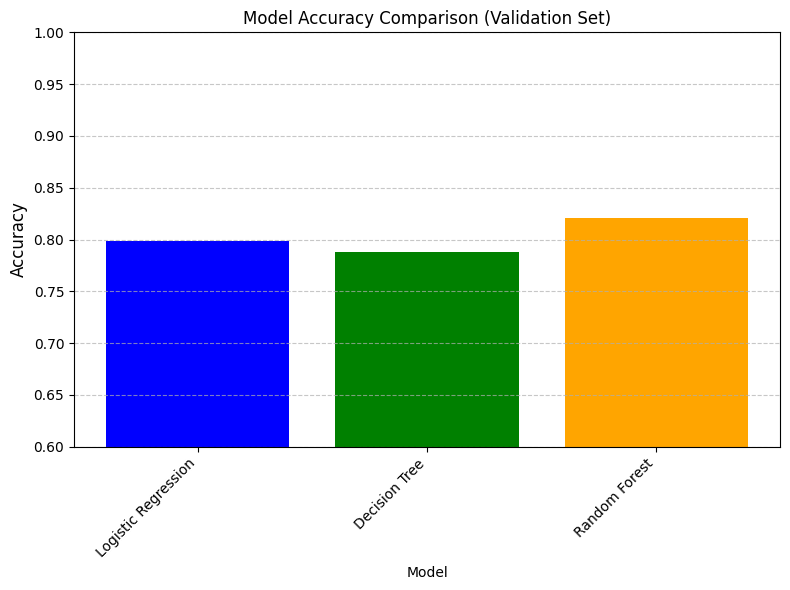

In [104]:
# 9. ompare Model Accuracies in Visualization

# Bar plot to compare model accuracies
plt.figure(figsize=(8, 6))
plt.bar(results['Model'], results['Accuracy'], color=['blue', 'green', 'orange'])
plt.title('Model Accuracy Comparison (Validation Set)')
plt.xlabel('Model')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.6, 1.0)  # Set y-axis limits for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


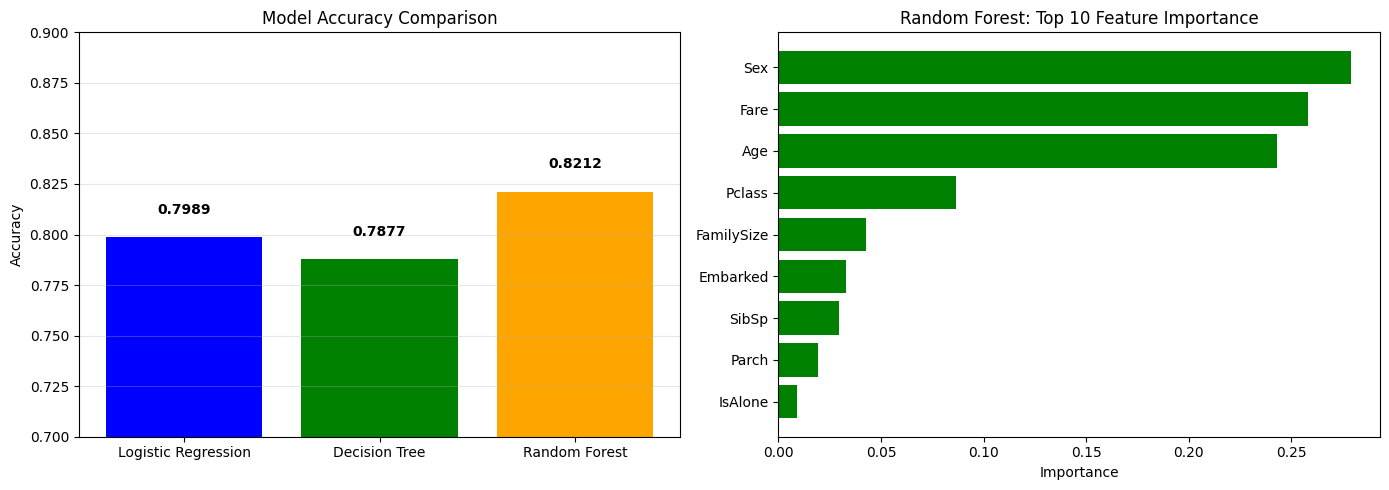


Random Forest Feature Importance:
       Feature  Importance
1         Sex    0.279290
5        Fare    0.257920
2         Age    0.242859
0      Pclass    0.086490
7  FamilySize    0.042812
6    Embarked    0.032882
3       SibSp    0.029642
4       Parch    0.019079
8     IsAlone    0.009026


In [105]:
# 10. Visualization: Model Performance Comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of accuracies
axes[0].bar(results['Model'], results['Accuracy'], color=['blue', 'green', 'orange'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim([0.7, 0.9])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(results['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Feature importance for Random Forest
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

axes[1].barh(feature_importance['Feature'], feature_importance['Importance'], color='green')
axes[1].set_xlabel('Importance')
axes[1].set_title('Random Forest: Top 10 Feature Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nRandom Forest Feature Importance:\n", feature_importance)


## 11. Evaluation Metrics

In [106]:
# 10. Detailed Model Evaluation Metrics
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics for all models
models_info = [
    ('Logistic Regression', y_pred),
    ('Decision Tree', y_pred_dt),
    ('Random Forest', y_pred_rf)
]

detailed_results = []
for model_name, predictions in models_info:
    detailed_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_val, predictions),
        'Precision': precision_score(y_val, predictions),
        'Recall': recall_score(y_val, predictions),
        'F1-Score': f1_score(y_val, predictions)
    })

metrics_df = pd.DataFrame(detailed_results)
print("\nDetailed Model Evaluation Metrics:\n")
print(metrics_df.to_string(index=False))

# Find best model
best_model_idx = metrics_df['F1-Score'].idxmax()
best_model = metrics_df.loc[best_model_idx, 'Model']
print(f"\n✓ Best Model (by F1-Score): {best_model}")



Detailed Model Evaluation Metrics:

              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.798883   0.779412 0.716216  0.746479
      Decision Tree  0.787709   0.743243 0.743243  0.743243
      Random Forest  0.821229   0.791667 0.770270  0.780822

✓ Best Model (by F1-Score): Random Forest


## 12. Confusion Matrices

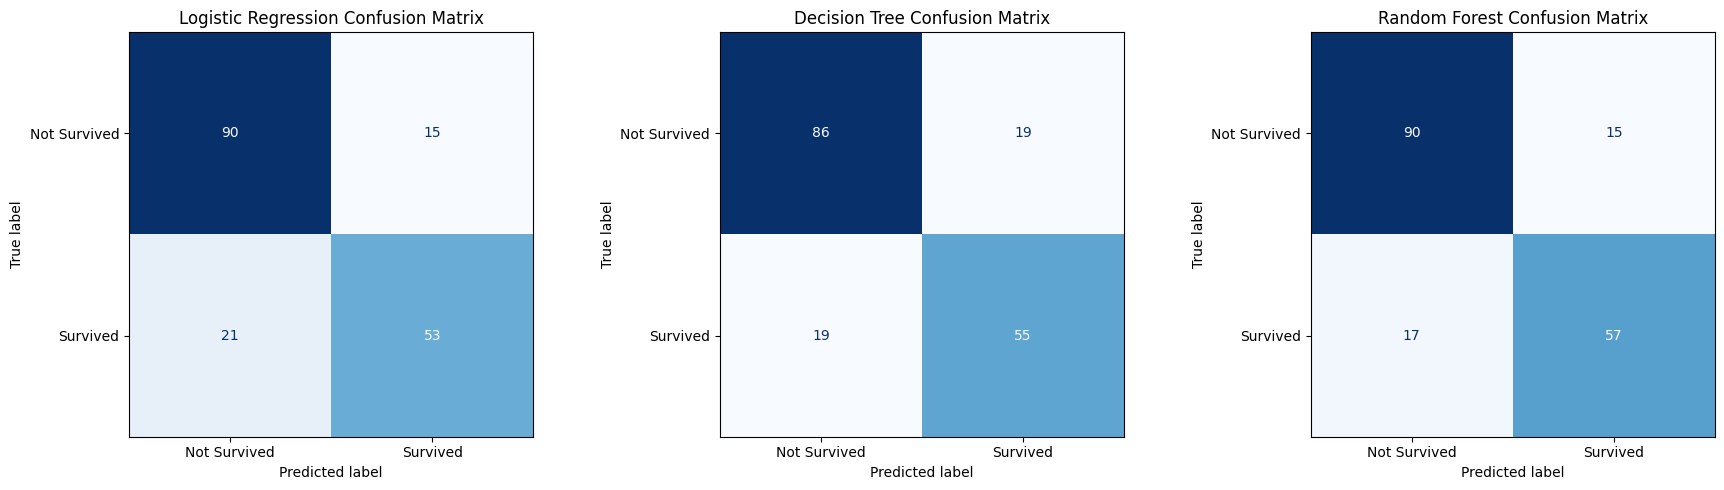

In [107]:
# Heat Map of Confusion Matrix for each Model
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, predictions) in zip(axes, models_info):
    cm_display = ConfusionMatrixDisplay(cm_func(y_val, predictions), display_labels=['Not Survived', 'Survived'])
    cm_display.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{model_name} Confusion Matrix')
plt.tight_layout()  
plt.show()


## 13. ROC Curves

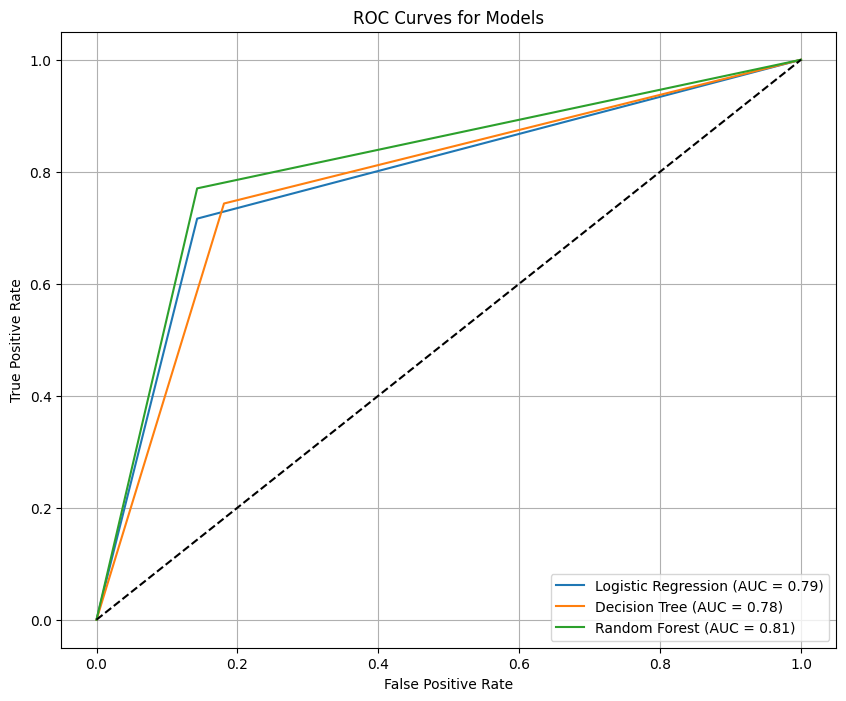

In [108]:
# 13. ROC Curves for all models
from sklearn.metrics import roc_curve, auc          
plt.figure(figsize=(10, 8))
for model_name, predictions in models_info:
    fpr, tpr, _ = roc_curve(y_val, predictions)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})') 
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing    
plt.title('ROC Curves for Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.show()


## 14. Hyperparameter Tuning

In [109]:
# 13. Hyperparameter Tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize Random Forest model
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf,                
                           param_grid=param_grid,
                           cv=5,                    # 5-fold cross-validation
                           n_jobs=-1,               # Use all available cores
                           verbose=2,               # Print progress messages
                           scoring='f1'             # Optimize for F1-Score
)

# Fit on training data
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best F1-Score from GridSearchCV:", grid_search.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Hyperparameters: {'bootstrap': True, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best F1-Score from GridSearchCV: 0.7581731530118627


In [110]:
# Evaluate Tuned Model
best_rf = grid_search.best_estimator_   
y_pred_best_rf = best_rf.predict(X_val)

print("Tuned Random Forest Validation Accuracy:", accuracy_score(y_val, y_pred_best_rf))
print("Tuned Random Forest Confusion Matrix:\n", cm_func(y_val, y_pred_best_rf))


Tuned Random Forest Validation Accuracy: 0.8044692737430168
Tuned Random Forest Confusion Matrix:
 [[93 12]
 [23 51]]


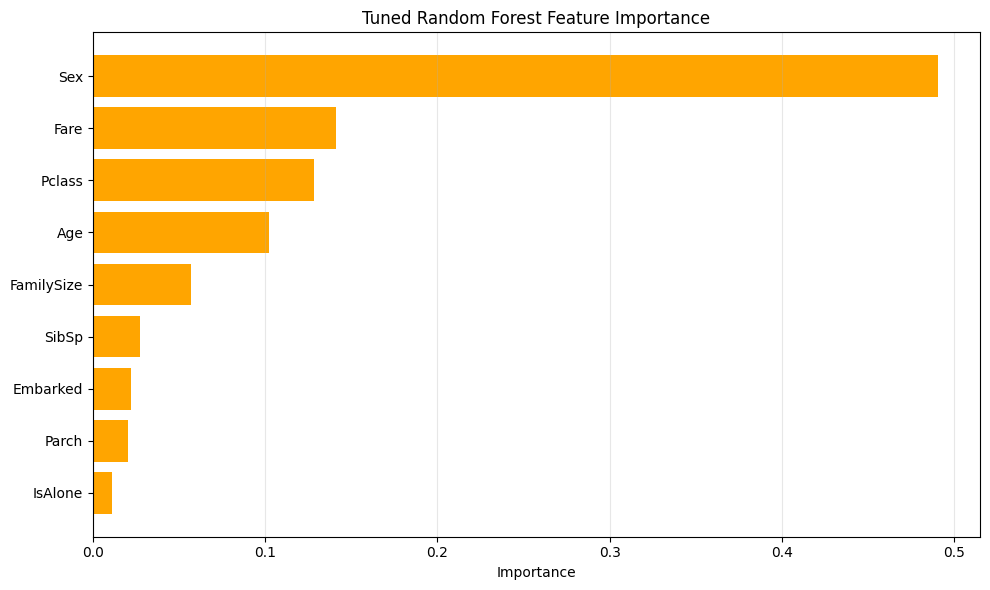

In [111]:
# Feature Importance from Tuned Random Forest
feature_importance_tuned = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)    

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_tuned['Feature'], feature_importance_tuned['Importance'], color='orange')
plt.xlabel('Importance')    
plt.title('Tuned Random Forest Feature Importance')
plt.gca().invert_yaxis()  # Invert y-axis to show most important feature at the top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()